In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/unsdsn/world-happiness/2015.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2017.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2019.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2018.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2016.csv


In [38]:
np.random.seed(42)
m = 1000
n = 5
X = np.random.random((m, n))
w = np.random.random((n,))
y = X @ w + np.random.random((m,))

In [39]:
w

array([0.39363552, 0.47343566, 0.85454739, 0.34000439, 0.86964968])

In [40]:
X.shape

(1000, 5)

In [41]:
y.shape

(1000,)

In [42]:
np.linalg.matrix_rank(X)

np.int64(5)

In [43]:
def model(X, w, b):
    return (np.dot(X, w) + b)

In [44]:
def cost_func(X, y, w, b):
    m = X.shape[0]
    
    sq_error = (model(X, w, b) - y)**2
    cost = np.sum(sq_error)/ m
    return cost

In [45]:
def learning_schedule(t):
   return (t0 / (t + t1))

In [46]:
def gradient_func(X, y, w, b, epoch):
    m = X.shape[0]
    dj_dw = np.zeros((X.shape[1],))
    dj_db = 0.0
    
    for i in range(m):
        random_index = np.random.randint(m)
        X_i = X[random_index:random_index+1]
        y_i = y[random_index:random_index+1]
        error =  y_i - model(X_i, w, b)
        dj_dw += 2 * (X_i.T @ error) / m
        dj_db += 2 * np.sum(error)/m
        alpha = learning_schedule(epoch*(m/100)+i)

    return dj_dw, dj_db, alpha

In [47]:
def gradient_descent(X, y, w, b, epoch):

    cost_history = []

    for e in range(epoch):
        dj_dw, dj_db, alpha = gradient_func(X, y, w, b, epoch)

        w = w - dj_dw * alpha
        b = b - dj_db * alpha

        cost = cost_func(X, y, w, b)
        cost_history.append(cost)
        

        if e % 200 == 0:
            print(f"Epoch: {e:4d} | Loss: {cost_history[-1]:8.2f}")
    return w, b, cost_history

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
w = np.zeros((n,))
b = 0
epoch = 400
t0, t1 = 15, 150
w_new, b_new, cost_history = gradient_descent(X_scaled, y, w, b, epoch)

Epoch:    0 | Loss:     4.09
Epoch:  200 | Loss:    41.24


In [50]:
from sklearn.linear_model import SGDRegressor, LinearRegression

sdg_reg, lin_reg = SGDRegressor().fit(X, y), LinearRegression().fit(X, y)
print("SGD:", sdg_reg.coef_, "Lin_Reg:", lin_reg.coef_)
print("SGD:", sdg_reg.intercept_, "Lin_Reg:", lin_reg.intercept_)

SGD: [0.32992827 0.41672225 0.68373287 0.31294092 0.67582707] Lin_Reg: [0.32318501 0.43822064 0.84716806 0.29016619 0.83551045]
SGD: [0.75512021] Lin_Reg: 0.5960722075128182


In [51]:
print(sdg_reg.predict(X[:10]))

[2.06815006 2.08967315 1.92459485 1.63320208 1.63774092 1.66576265
 2.02065092 1.7271458  1.48470195 1.75520724]


In [52]:
y[:10]

array([1.65042037, 2.42604768, 2.25652227, 1.24661108, 1.50807213,
       1.25036245, 2.24446407, 1.69666286, 1.48140381, 1.39591969])

In [65]:
def stochastic_grad_descent(X, y, w, b, epoch):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0
    cost_history = []

    for e in range(epoch):
        for i in range(m):
            random_index = np.random.randint(m)
            X_i = X[random_index:random_index+1]
            y_i = y[random_index:random_index+1]
            error = model(X_i, w, b) - y_i
            dj_dw += 2 * (X_i.T @ error) / m + (lambda / 2*m) *
            dj_db += 2 * np.sum(error) / m
            alpha = learning_schedule(epoch * m + i)

            w = w - dj_dw * alpha
            b = b - dj_db * alpha

            cost = cost_func(X_i, y_i, w, b)
            cost_history.append(cost)
        

        if e % 500 == 0:
            print(f"Epoch: {e:4d} | Loss: {cost_history[-1]:8.2f}")
    return w, b, cost_history

In [54]:
w_init = np.zeros((n,))
b_init = 0.0
epoch = 2000
t0, t1 = 200, 2000
w, b, cost_history = stochastic_grad_descent(X, y, w_init, b_init, epoch)
print(f"weights: {w} | Bias: {b}")

Epoch:    0 | Loss:     3.93
Epoch:  500 | Loss:     0.03
Epoch: 1000 | Loss:     4.82
Epoch: 1500 | Loss:     0.06
weights: [-0.52165541  0.51366078 -0.57715582 -0.08320428  1.33768404] | Bias: -0.2954827406036438


In [55]:
print(model(X_scaled[:10], w, b))
print(sdg_reg.predict(X_scaled[:10]))

[-1.40966988 -0.27738219 -0.71212627 -1.09004981 -0.89172921 -3.5113323
  1.82015447 -0.73131768  0.05538111 -2.45477241]
[ 1.13545032  1.25041033  0.63996608 -0.35210208 -0.34042393 -0.23741632
  0.98060098 -0.04247695 -0.88606137  0.06825235]


In [66]:
def mini_batch_gradient_descent(X, y, w, b, batch_size, epoch):
    m, n = X.shape
    cost_history = []

    for e in range(epoch):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        alpha = learning_schedule(epoch * m + e)
        for start in range(0, m, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            error = model(X_batch, w, b) - y_batch
            dj_dw = 2 * (X_batch.T @ error) / m
            dj_db = 2 * np.sum(error) / m

            w = w - dj_dw * alpha
            b = b - dj_db * alpha

        cost_history.append(cost_func(X_batch, y_batch, w, b))
        if e % 50 == 0:
            print(f"Epoch: {e:4d} | Loss: {cost_history[-1]:8.2f}")
    return w, b, cost_history

In [91]:
w_init = np.zeros((5,))
b_init = 0.0
batch_size = 80
epoch = 10000
t0, t1 = 1000, 10000
w, b, cost_history = mini_batch_gradient_descent(X_scaled, y, w_init, b_init, batch_size, epoch)
print(f"weights {w} | bias: {b}")

Epoch:    0 | Loss:     4.29
Epoch:   50 | Loss:     3.92
Epoch:  100 | Loss:     4.12
Epoch:  150 | Loss:     4.13
Epoch:  200 | Loss:     3.76
Epoch:  250 | Loss:     3.85
Epoch:  300 | Loss:     3.74
Epoch:  350 | Loss:     3.34
Epoch:  400 | Loss:     3.50
Epoch:  450 | Loss:     2.96
Epoch:  500 | Loss:     3.07
Epoch:  550 | Loss:     3.39
Epoch:  600 | Loss:     3.25
Epoch:  650 | Loss:     3.20
Epoch:  700 | Loss:     3.21
Epoch:  750 | Loss:     3.21
Epoch:  800 | Loss:     2.70
Epoch:  850 | Loss:     3.05
Epoch:  900 | Loss:     2.67
Epoch:  950 | Loss:     2.91
Epoch: 1000 | Loss:     2.92
Epoch: 1050 | Loss:     2.42
Epoch: 1100 | Loss:     3.05
Epoch: 1150 | Loss:     2.59
Epoch: 1200 | Loss:     2.60
Epoch: 1250 | Loss:     2.34
Epoch: 1300 | Loss:     2.27
Epoch: 1350 | Loss:     2.49
Epoch: 1400 | Loss:     2.12
Epoch: 1450 | Loss:     2.17
Epoch: 1500 | Loss:     2.03
Epoch: 1550 | Loss:     2.19
Epoch: 1600 | Loss:     2.20
Epoch: 1650 | Loss:     2.34
Epoch: 1700 | 

In [92]:
from sklearn.linear_model import SGDRegressor, LinearRegression

sdg_reg, lin_reg = SGDRegressor().fit(X_scaled, y), LinearRegression().fit(X_scaled, y)
print("SGD:", sdg_reg.coef_, "Lin_Reg:", lin_reg.coef_)
print("SGD:", sdg_reg.intercept_, "Lin_Reg:", lin_reg.intercept_)

SGD: [0.09274883 0.13157702 0.24256839 0.08097716 0.23982653] Lin_Reg: [0.09377931 0.13012882 0.24132437 0.0832378  0.24138906]
SGD: [1.95746184] Lin_Reg: 1.9528683211767648


In [93]:
y_pred_mbgd = model(X_scaled, w, b)

In [94]:
y_pred = sdg_reg.predict(X_scaled)

In [95]:
from sklearn.metrics import mean_squared_error
print(f"The MSE for Mini-Batch: {mean_squared_error(y, y_pred_mbgd)} | MSE sklearn SGD: {mean_squared_error(y, y_pred)}")

The MSE for Mini-Batch: 0.15582808776570398 | MSE sklearn SGD: 0.08285887769227844


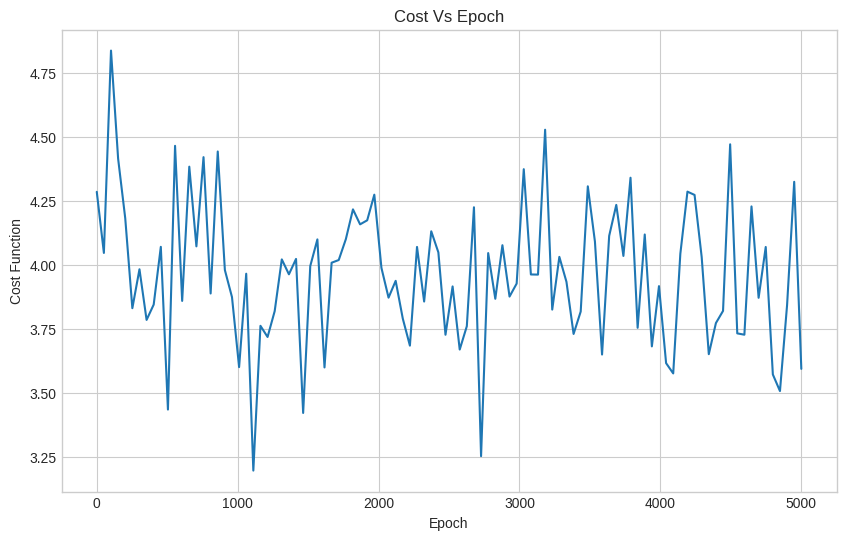

In [96]:
plt.figure(figsize=(10, 6))
epoch = np.linspace(0, 5000, 100)
plt.plot(epoch, cost_history[:100])
plt.xlabel("Epoch")
plt.ylabel("Cost Function")
plt.title("Cost Vs Epoch")
plt.show()